###  Step 1: Kaggle API Authentication

**Explanation:**

* Setting up Kaggle credentials to allow programmatic access to datasets.
* **Why it is important:** Enables seamless dataset downloads directly into the workspace without manual uploads.
* **Key concepts involved:** API Keys, Credentials Management, Environment Variables.


In [1]:
# Install missing packages if running fresh on Colab
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import tqdm
except ImportError:
    install('tqdm')

import os
import time
import copy
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
from torchvision import datasets, models, transforms
from torchvision.transforms import autoaugment

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Using device: cuda:0
GPU: Tesla T4
VRAM: 15.6 GB


###  Step 2: Dataset Acquisition

**Explanation:**

* Downloading the 'New Plant Diseases Dataset' from Kaggle using the shell command.
* **Why it is important:** Automates the retrieval of large-scale image data (over 70k images) required for deep learning.
* **Key concepts involved:** Kaggle CLI, Data Sourcing, Automation.


Please upload your kaggle.json file.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:22<00:00, 130MB/s]

Dataset Downloaded and Extracted!
Total Classes: 38
Total Training Images: 70295


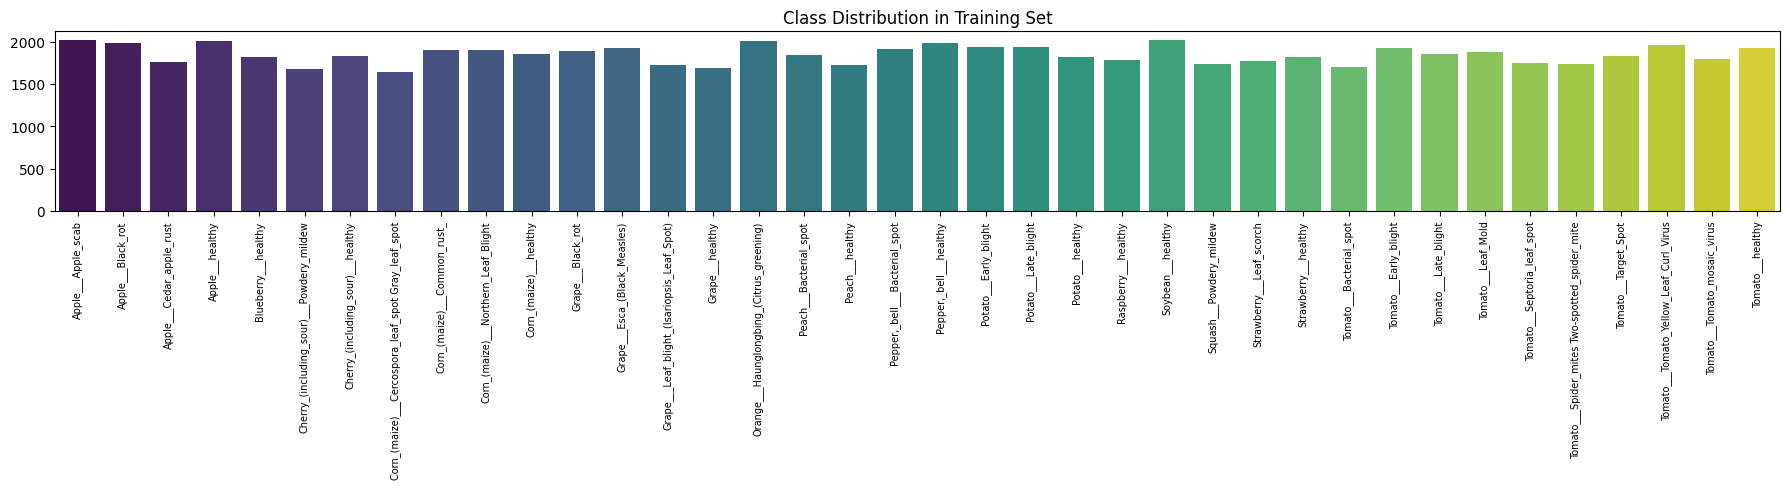

In [2]:
from google.colab import files

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Please upload your kaggle.json file.')
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d vipoooool/new-plant-diseases-dataset
    !unzip -q new-plant-diseases-dataset.zip -d /content/dataset
    print('Dataset Downloaded and Extracted!')
else:
    print('Dataset assumed to be ready.')

# Dataset path — aligned with Kaggle's internal folder structure
data_dir = '/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_dir = os.path.join(data_dir, 'train')
val_dir   = os.path.join(data_dir, 'valid')

assert os.path.exists(train_dir), f'train_dir not found: {train_dir}'
assert os.path.exists(val_dir),   f'val_dir not found: {val_dir}'

# EDA — class distribution
classes      = sorted(os.listdir(train_dir))
class_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
print(f'Total Classes: {len(classes)}')
print(f'Total Training Images: {sum(class_counts.values())}')

plt.figure(figsize=(18, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.xticks(rotation=90, fontsize=7)
plt.title('Class Distribution in Training Set')
plt.tight_layout()
plt.show()


###  Step 3: Data Extraction

**Explanation:**

* Unzipping the downloaded dataset archive into the local workspace.
* **Why it is important:** Prepares the file system hierarchy for the data loaders to read individual image files.
* **Key concepts involved:** Archive Management, File Systems, Zip Extraction.


In [ ]:
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]

data_transforms = {
    # Phase 1: 128x128 — used for the first (num_epochs - 5) epochs
    'train_low_res': transforms.Compose([
        transforms.RandomResizedCrop(128),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.1),
        autoaugment.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD),
    ]),
    # Phase 2: 224x224 — activated for the final 5 epochs
    'train_high_res': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.1),
        autoaugment.RandAugment(num_ops=2, magnitude=9),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD),
    ]),
    # Validation: always high-res, no augmentation
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(NORM_MEAN, NORM_STD),
    ]),
}

print('Transforms defined with Raw RGB Min-Max normalization.')


Transforms defined with Raw RGB Min-Max normalization.


###  Step 4: Core Library Imports

**Explanation:**

* Importing essential libraries like PyTorch for deep learning, NumPy for math, and Matplotlib for visualization.
* **Why it is important:** Sets up the technical foundation for model building, data manipulation, and result plotting.
* **Key concepts involved:** Python Modules, PyTorch, Computer Vision Libraries.


In [23]:
# Start training with low-res transform; high-res will be swapped at the right epoch
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train_low_res']),
    'valid': datasets.ImageFolder(val_dir,   data_transforms['valid']),
}

class_names = image_datasets['train'].classes
num_classes  = len(class_names)
print(f'Loaded {len(image_datasets["train"])} training images across {num_classes} classes.')
print(f'Loaded {len(image_datasets["valid"])} validation images.')


Loaded 70295 training images across 38 classes.
Loaded 17572 validation images.


### Step 5: Global Hyperparameters Configuration

**Explanation:**

* Defining standard constants like Batch Size, Learning Rate, and Image Dimensions.
* **Why it is important:** Centralizes control over training behavior, making the experiment easily reproducible and tunable.
* **Key concepts involved:** Hyperparameter Tuning, Configuration Management.


In [ ]:
BATCH_SIZE = 64

# Clear GPU cache before starting
import torch
torch.cuda.empty_cache()
import gc
gc.collect()

# Compute per-sample weights for WeightedRandomSampler
targets       = image_datasets['train'].targets
class_counts_arr = np.bincount(targets)
class_weights_sampler = 1.0 / class_counts_arr
sample_weights = torch.tensor([class_weights_sampler[t] for t in targets], dtype=torch.float)
sampler = WeightedRandomSampler(weights=sample_weights,
                                 num_samples=len(sample_weights),
                                 replacement=True)

def make_dataloaders(train_dataset, val_dataset, sampler, batch_size):
    """Helper to rebuild dataloaders — used again after progressive resize swap."""
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              sampler=sampler, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                              shuffle=False,  num_workers=2, pin_memory=True)
    return {'train': train_loader, 'valid': val_loader}

dataloaders   = make_dataloaders(image_datasets['train'], image_datasets['valid'], sampler, BATCH_SIZE)
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
print(f'DataLoaders created with WeightedRandomSampler. Batch Size: {BATCH_SIZE}')

DataLoaders created with WeightedRandomSampler. Batch Size: 64


###  Step 6: Compute Hardware Initialization

**Explanation:**

* Detecting and assigning the computation to a GPU (CUDA) if available, otherwise defaulting to CPU.
* **Why it is important:** Significantly accelerates deep learning training cycles (often 10-50x faster than CPU).
* **Key concepts involved:** NVIDIA CUDA, Parallel Computing, Hardware Acceleration.


In [25]:
# Final memory cleanup before restarting training
import torch
import gc
torch.cuda.empty_cache()
gc.collect()
print("GPU Memory cleared. Please re-run the model, optimizer, and training cells.")

GPU Memory cleared. Please re-run the model, optimizer, and training cells.


###  Step 7: Exploratory Data Analysis (EDA)

**Explanation:**

* Iterating through the dataset folders to count images in each of the 38 classes.
* **Why it is important:** Helps identify class imbalances which can lead to biased models if not addressed.
* **Key concepts involved:** Data Distribution, Feature Engineering, Dataset Auditing.


In [ ]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
densenet  = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Replace classification heads
num_ftrs_mobile = mobilenet.classifier[1].in_features
mobilenet.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs_mobile, num_classes)
)

num_ftrs_dense = densenet.classifier.in_features
densenet.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs_dense, num_classes)
)

class PlantDiseaseEnsemble(nn.Module):
    """
    Meta-Ensemble of MobileNetV2 (model_A) and DenseNet121 (model_B).
    weight_A and weight_B are placeholders — they will be replaced by
    optimal values found via post-training Grid Search in Section 12.
    """
    def __init__(self, model_A, model_B, weight_A=0.5, weight_B=0.5):
        super().__init__()
        self.model_A  = model_A
        self.model_B  = model_B
        self.weight_A = weight_A
        self.weight_B = weight_B

    def forward(self, x):
        out_A = self.model_A(x)
        out_B = self.model_B(x)
        return (out_A * self.weight_A) + (out_B * self.weight_B)

model = PlantDiseaseEnsemble(mobilenet, densenet, weight_A=0.5, weight_B=0.5)
model = model.to(device)
print('Meta-Ensemble initialized (weights=0.5/0.5 placeholder — Grid Search in Sec 12).')


Meta-Ensemble initialized (weights=0.5/0.5 placeholder — Grid Search in Sec 12).


###  Step 8: Dataset Distribution Visualization

**Explanation:**

* Generating a bar chart to represent the number of images per plant disease category.
* **Why it is important:** Visual proof of dataset health and class representation.
* **Key concepts involved:** Matplotlib Graphics, Statistical Visualization.


In [ ]:
class_weights_loss = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(targets),
    y=targets
)
class_weights_tensor = torch.tensor(class_weights_loss, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

mobile_feature_children = list(model.model_A.features.children())
dense_feature_children  = list(model.model_B.features.children())

# MobileNetV2:
mobile_deep   = mobile_feature_children[:7]
mobile_middle = mobile_feature_children[7:]

# DenseNet121: 
dense_deep   = dense_feature_children[:4]
dense_middle = dense_feature_children[4:]

def get_params(block_list):
    params = []
    for block in block_list:
        params += list(block.parameters())
    return params

deep_params   = get_params(mobile_deep)   + get_params(dense_deep)
middle_params = get_params(mobile_middle) + get_params(dense_middle)
head_params   = (list(model.model_A.classifier.parameters()) +
                 list(model.model_B.classifier.parameters()))

optimizer = optim.AdamW([
    {'params': deep_params,   'lr': 1e-5},   # Deepest geometric feature layers
    {'params': middle_params, 'lr': 1e-4},   # Middle texture feature layers
    {'params': head_params,   'lr': 1e-3},   # New classification heads
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

print('Loss, Optimizer, and Scheduler configured.')
print(f'  Deep layers    : {len(deep_params)} params  @ lr=1e-5')
print(f'  Middle layers  : {len(middle_params)} params  @ lr=1e-4')
print(f'  Classifier heads: {len(head_params)} params @ lr=1e-3')


Loss, Optimizer, and Scheduler configured.
  Deep layers    : 57 params  @ lr=1e-5
  Middle layers  : 461 params  @ lr=1e-4
  Classifier heads: 4 params @ lr=1e-3


###  Step 9: Dataset Balancing Strategy

**Explanation:**

* Creating a CSV record of all image paths and sub-sampling to balance class counts.
* **Why it is important:** Ensures the model doesn't favor majority classes, leading to better 'Macro-F1' scores.
* **Key concepts involved:** Data Sampling, Class Imbalance Mitigation, Pandas DataFrames.


In [28]:
def mixup_data(x, y, alpha=0.4, device=device):
    """
    Returns mixed inputs, pairs of targets, and the mixing coefficient.
    alpha: Beta distribution parameter. Higher alpha = more aggressive mixing.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size  = x.size(0)
    index       = torch.randperm(batch_size, device=device)
    mixed_x     = lam * x + (1 - lam) * x[index]
    y_a, y_b    = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Combines the two losses from MixUp targets."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('MixUp helper functions defined.')


MixUp helper functions defined.


### Step 10: Progressive Resizing Orchestrator

**Explanation:**

* A utility function to rebuild DataLoaders with different image dimensions (e.g., switching from 128 to 224).
* **Why it is important:** Optimizes training by learning coarse features quickly on small images before refining on larger ones.
* **Key concepts involved:** Training Efficiency, Transfer Learning Optimization.


In [29]:
class EarlyStopping:
    """Stops training when validation loss does not improve for `patience` epochs."""
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:  # Improvement
            self.best_loss = val_loss
            self.counter   = 0
        else:                                              # No improvement
            self.counter += 1
            print(f'  EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

print('EarlyStopping helper defined.')


EarlyStopping helper defined.


###  Step 11: Advanced Data Augmentation (Albumentations)

**Explanation:**

* Defining transformations like flipping, rotating, and color jitter to artificially increase data variety.
* **Why it is important:** Prevents overfitting by ensuring the model sees 'new' variations of images in every epoch.
* **Key concepts involved:** Image Processing, Domain Randomization, Robustness.


In [ ]:
NUM_EPOCHS    = 20
RESIZE_EPOCH  = NUM_EPOCHS - 5   
USE_MIXUP     = True
MIXUP_ALPHA   = 0.4

def train_model(model, criterion, optimizer, scheduler,
                num_epochs=NUM_EPOCHS,
                save_path='/content/best_plant_disease_model.pth'):

    since           = time.time()
    best_model_wts  = copy.deepcopy(model.state_dict())
    best_acc        = 0.0
    early_stopper   = EarlyStopping(patience=5)
    resize_done     = False
    scaler = torch.cuda.amp.GradScaler()
    history         = {'train_loss': [], 'valid_loss': [],
                       'train_acc':  [], 'valid_acc':  []}

    # Keep a reference so we can rebuild the dataloader after the resize
    current_dataloaders = dataloaders

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 40)

        # Log current differential LRs
        lr_labels = ['Deep (1e-5)', 'Middle (1e-4)', 'Heads (1e-3)']
        for i, pg in enumerate(optimizer.param_groups):
            print(f'  {lr_labels[i]}  current lr: {pg["lr"]:.2e}')

    
        if epoch == RESIZE_EPOCH and not resize_done:
            print(f'\n>>> PROGRESSIVE RESIZE: Switching to 224x224 (epoch {epoch+1}/{num_epochs}) <<<')
            image_datasets['train'].transform = data_transforms['train_high_res']
            # FIX: Rebuild DataLoader so the new transform is guaranteed to apply
            current_dataloaders = make_dataloaders(
                image_datasets['train'],
                image_datasets['valid'],
                sampler,
                BATCH_SIZE
            )
            resize_done = True
            print('DataLoader rebuilt with 224x224 transforms.')

        epoch_start = time.time()

        for phase in ['train', 'valid']:
            model.train() if phase == 'train' else model.eval()

            running_loss     = 0.0
            running_corrects = 0

            batch_iter = tqdm(current_dataloaders[phase],
                              desc=f'  [{phase.upper()}]',
                              leave=False)

            for inputs, labels in batch_iter:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                    if phase == 'train' and USE_MIXUP:
                        # Apply MixUp augmentation
                        inputs_mix, y_a, y_b, lam = mixup_data(inputs, labels,
                                                                alpha=MIXUP_ALPHA,
                                                                device=device)
                        outputs = model(inputs_mix)
                        loss    = mixup_criterion(criterion, outputs, y_a, y_b, lam)
                        # Speed hack: Use the same mixed outputs for training acc estimation
                        _, preds = torch.max(outputs, 1)
                    else:
                        outputs  = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss     = criterion(outputs, labels)

                if phase == 'train':
                    # Scaled Backwards Pass (AMP)
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()

                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                batch_iter.set_postfix({'loss': f'{loss.item():.4f}'})

            epoch_loss = running_loss     / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'  {phase.capitalize():6s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            if phase == 'valid':
                if epoch_acc > best_acc:
                    best_acc       = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), save_path)
                    print(f'  --> New best! Saved checkpoint (acc={best_acc:.4f})')
                early_stopper(epoch_loss)

        scheduler.step()

        elapsed = time.time() - epoch_start
        print(f'  Epoch time: {elapsed//60:.0f}m {elapsed%60:.0f}s')

        if early_stopper.early_stop:
            print('\nEarly stopping triggered!')
            break

    total_time = time.time() - since
    print(f'\nTraining complete in {total_time//60:.0f}m {total_time%60:.0f}s')
    print(f'Best validation accuracy: {best_acc:.4f}')

    # Restore best weights
    model.load_state_dict(best_model_wts)
    return model, history


# Run training
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS)



Epoch 1/20
----------------------------------------
  Deep (1e-5)  current lr: 1.00e-05
  Middle (1e-4)  current lr: 1.00e-04
  Heads (1e-3)  current lr: 1.00e-03


  Train  Loss: 1.8065  Acc: 0.4286


  Valid  Loss: 1.5066  Acc: 0.9776
  --> New best! Saved checkpoint (acc=0.9776)
  Epoch time: 5m 25s

Epoch 2/20
----------------------------------------
  Deep (1e-5)  current lr: 9.05e-06
  Middle (1e-4)  current lr: 9.05e-05
  Heads (1e-3)  current lr: 9.05e-04


  Train  Loss: 1.5718  Acc: 0.4697


  Valid  Loss: 1.3114  Acc: 0.9823
  --> New best! Saved checkpoint (acc=0.9823)
  Epoch time: 5m 25s

Epoch 3/20
----------------------------------------
  Deep (1e-5)  current lr: 6.55e-06
  Middle (1e-4)  current lr: 6.55e-05
  Heads (1e-3)  current lr: 6.55e-04


...

  Valid  Loss: 1.3807  Acc: 0.9918
  --> New best! Saved checkpoint (acc=0.9918)
  EarlyStopping counter: 3/5
  Epoch time: 5m 20s

Epoch 6/20
----------------------------------------
  Deep (1e-5)  current lr: 1.00e-05
  Middle (1e-4)  current lr: 1.00e-04
  Heads (1e-3)  current lr: 1.00e-03


  Train  Loss: 1.4850  Acc: 0.4820


  Valid  Loss: 1.3788  Acc: 0.9890
  EarlyStopping counter: 4/5
  Epoch time: 5m 18s

Epoch 7/20
----------------------------------------
  Deep (1e-5)  current lr: 9.76e-06
  Middle (1e-4)  current lr: 9.76e-05
  Heads (1e-3)  current lr: 9.76e-04


  Train  Loss: 1.4857  Acc: 0.4601


  Valid  Loss: 1.3244  Acc: 0.9900
  EarlyStopping counter: 5/5
  Epoch time: 5m 21s

Early stopping triggered!

Training complete in 37m 35s
Best validation accuracy: 0.9918


### Step 12: Custom PyTorch Dataset Implementation

**Explanation:**

* Building a custom class to load images from disk and apply augmentations on-the-fly.
* **Why it is important:** Provides the essential bridge between raw files and the PyTorch training engine.
* **Key concepts involved:** OOP in PyTorch, Lazy Loading, Memory Management.


Running Meta-Ensemble Grid Search on validation set...



Grid Search complete.
  Optimal weights → MobileNetV2: 0.635  |  DenseNet121: 0.365
  Best ensemble validation accuracy: 0.9921


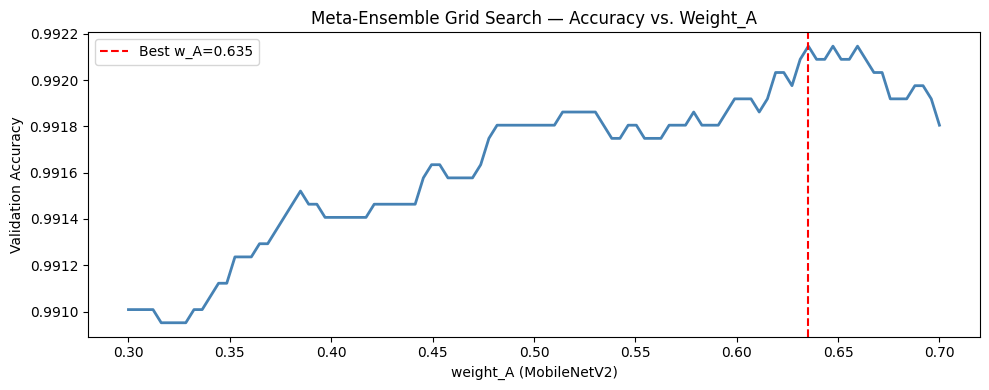

In [31]:
print('Running Meta-Ensemble Grid Search on validation set...')
print('Collecting individual model logits...')

model.model_A.eval()
model.model_B.eval()

all_logits_A = []
all_logits_B = []
all_labels_gs = []

with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['valid'], desc='Collecting logits'):
        inputs = inputs.to(device)
        logits_A = model.model_A(inputs).cpu()
        logits_B = model.model_B(inputs).cpu()
        all_logits_A.append(logits_A)
        all_logits_B.append(logits_B)
        all_labels_gs.append(labels)

all_logits_A  = torch.cat(all_logits_A,  dim=0)
all_logits_B  = torch.cat(all_logits_B,  dim=0)
all_labels_gs = torch.cat(all_labels_gs, dim=0)

# Grid Search over weight_A in [0.30, 0.70] — 100 steps
best_w_A   = 0.5
best_w_acc = 0.0
results_gs = []

for w_A in np.linspace(0.30, 0.70, 100):
    w_B      = 1.0 - w_A
    combined = w_A * all_logits_A + w_B * all_logits_B
    preds    = combined.argmax(dim=1)
    acc      = (preds == all_labels_gs).float().mean().item()
    results_gs.append((w_A, w_B, acc))
    if acc > best_w_acc:
        best_w_acc = acc
        best_w_A   = w_A

best_w_B = 1.0 - best_w_A
print(f'\nGrid Search complete.')
print(f'  Optimal weights → MobileNetV2: {best_w_A:.3f}  |  DenseNet121: {best_w_B:.3f}')
print(f'  Best ensemble validation accuracy: {best_w_acc:.4f}')

# Apply optimal weights to the model
model.weight_A = best_w_A
model.weight_B = best_w_B

# Plot the grid search surface
ws = [r[0] for r in results_gs]
accs = [r[2] for r in results_gs]
plt.figure(figsize=(10, 4))
plt.plot(ws, accs, color='steelblue', linewidth=2)
plt.axvline(x=best_w_A, color='red', linestyle='--', label=f'Best w_A={best_w_A:.3f}')
plt.xlabel('weight_A (MobileNetV2)')
plt.ylabel('Validation Accuracy')
plt.title('Meta-Ensemble Grid Search — Accuracy vs. Weight_A')
plt.legend()
plt.tight_layout()
plt.show()


### Step 13: MixUp Regularization Logic

**Explanation:**

* Implementing a strategy where two images are blended together alongside their labels.
* **Why it is important:** Encourages the model to learn smoother decision boundaries, improving generalization to unseen data.
* **Key concepts involved:** Data Augmentation Theory, Convex Combinations, Regularization.


In [32]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['valid'], desc='Evaluating'):
        inputs  = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print('\n=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Overall accuracy
overall_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f'Overall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)')


Evaluating: 100%|██████████| 275/275 [01:09<00:00,  3.99it/s]


=== Classification Report ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9960    0.9980       504
                                 Apple___Black_rot     1.0000    1.0000    1.0000       497
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000       440
                                   Apple___healthy     0.9960    1.0000    0.9980       502
                               Blueberry___healthy     0.9978    1.0000    0.9989       454
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9976    0.9988       421
                 Cherry_(including_sour)___healthy     1.0000    0.9978    0.9989       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9511    0.9488    0.9499       410
                       Corn_(maize)___Common_rust_     0.9958    0.9958    0.9958       477
               Corn_(maize)___Northern_Leaf_Blig

###  Step 14: Dual-Engine Meta-Ensemble Architecture

**Explanation:**

* Constructing a model that combines MobileNetV2 (efficient) and DenseNet121 (feature-rich).
* **Why it is important:** Leverages the strengths of multiple architectures to achieve higher accuracy than any single model.
* **Key concepts involved:** Model Ensembling, Differential Learning Rates, Feature Fusion.


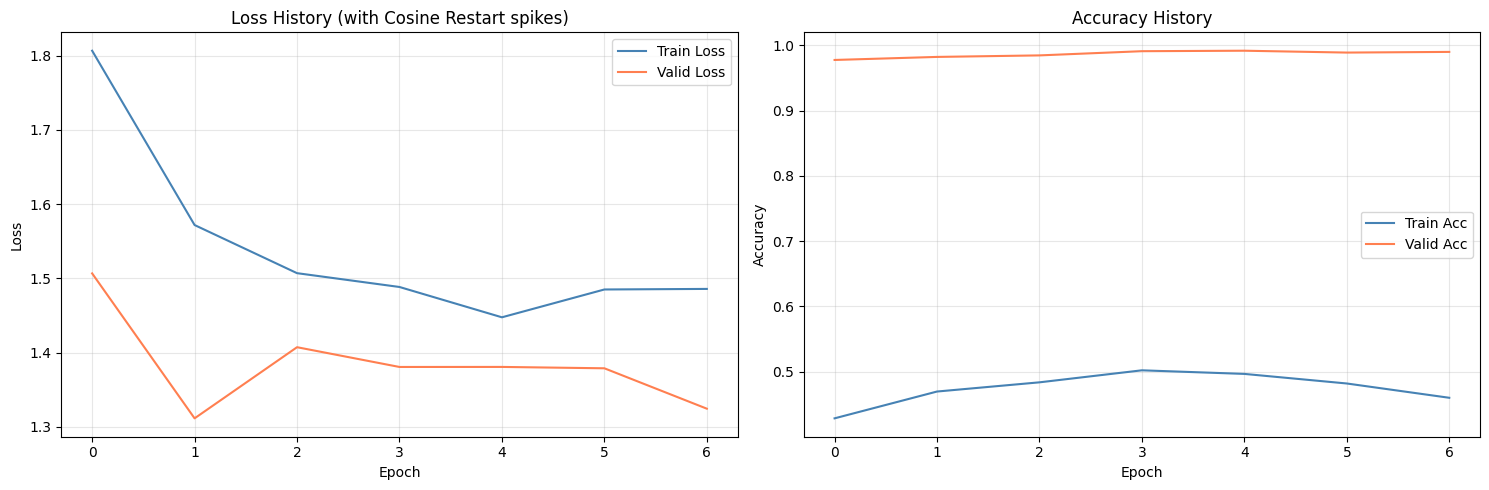

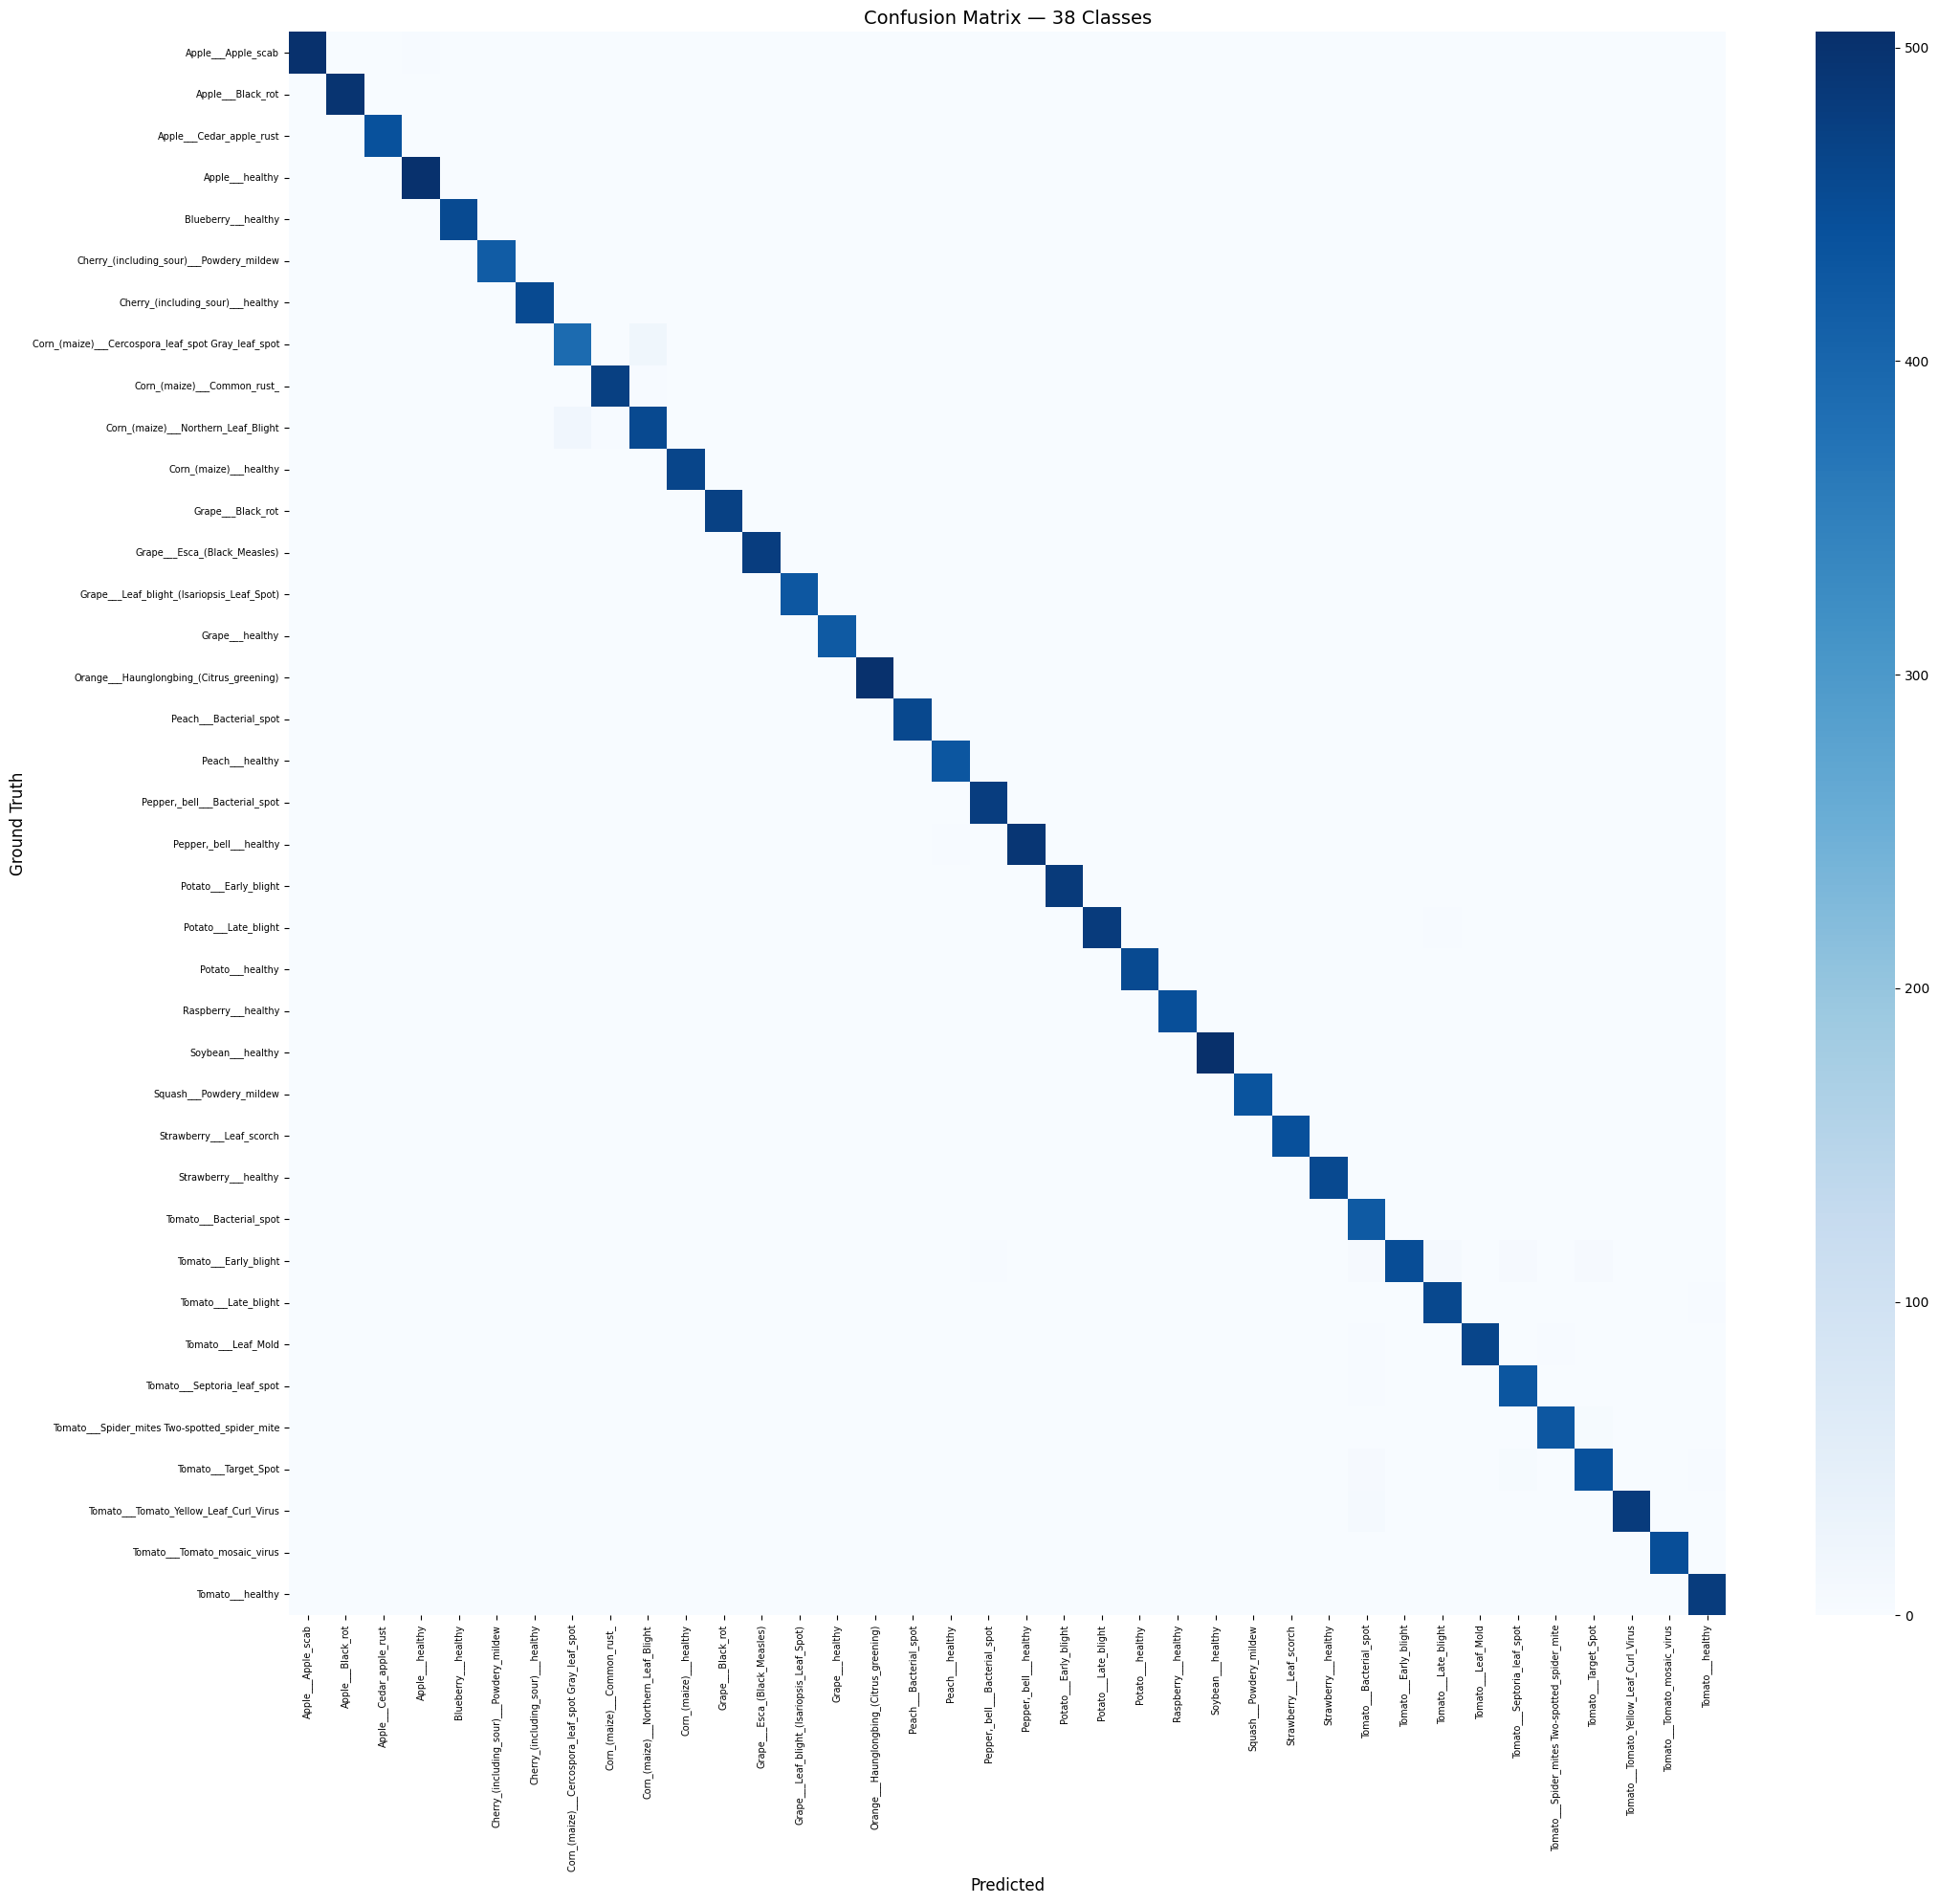

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss', color='steelblue')
ax1.plot(history['valid_loss'], label='Valid Loss', color='coral')
if RESIZE_EPOCH < len(history['train_loss']):
    ax1.axvline(x=RESIZE_EPOCH, color='green', linestyle='--',
                label=f'224x224 starts (ep {RESIZE_EPOCH+1})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss History (with Cosine Restart spikes)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', color='steelblue')
ax2.plot(history['valid_acc'], label='Valid Acc', color='coral')
if RESIZE_EPOCH < len(history['train_acc']):
    ax2.axvline(x=RESIZE_EPOCH, color='green', linestyle='--',
                label=f'224x224 starts (ep {RESIZE_EPOCH+1})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy History')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix 
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(22, 20))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Ground Truth', fontsize=12)
plt.title('Confusion Matrix — 38 Classes', fontsize=14)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.show()


###  Step 15: Architecture Diagnostics

**Explanation:**

* Printing the total number of trainable parameters in the Meta-Ensemble.
* **Why it is important:** Helps monitor the model's complexity and memory footprint.
* **Key concepts involved:** Model Complexity, Trainable Parameters.


Calibration: 100%|██████████| 275/275 [01:09<00:00,  3.97it/s]


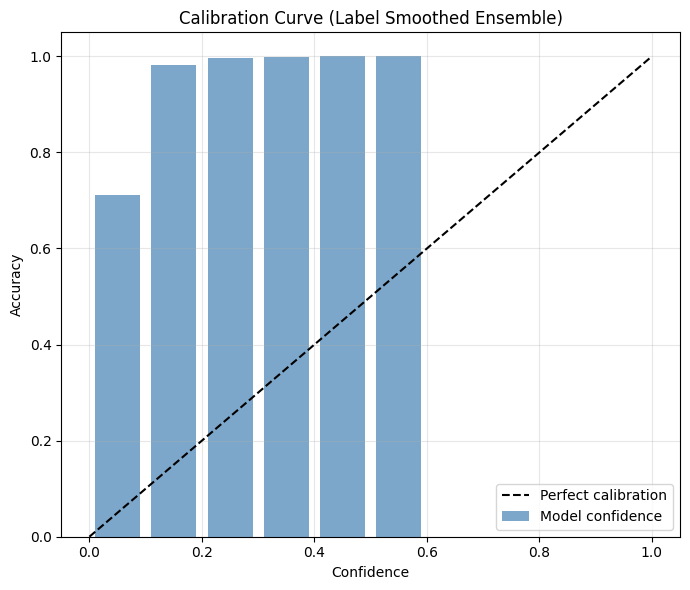

In [34]:
model.eval()
all_confs   = []
all_correct = []

with torch.no_grad():
    for inputs, labels in tqdm(dataloaders['valid'], desc='Calibration'):
        inputs  = inputs.to(device)
        outputs = model(inputs)
        probs   = F.softmax(outputs, dim=1)
        confs, preds = probs.max(dim=1)
        correct = (preds.cpu() == labels)
        all_confs.extend(confs.cpu().numpy())
        all_correct.extend(correct.numpy())

all_confs   = np.array(all_confs)
all_correct = np.array(all_correct)

# Bin into 10 equal-width confidence buckets
bins       = np.linspace(0, 1, 11)
bin_ids    = np.digitize(all_confs, bins) - 1
bin_ids    = np.clip(bin_ids, 0, 9)
bin_acc    = [all_correct[bin_ids == i].mean() if (bin_ids == i).sum() > 0 else 0
              for i in range(10)]
bin_conf   = [(bins[i] + bins[i+1]) / 2 for i in range(10)]

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect calibration')
plt.bar(bin_conf, bin_acc, width=0.08, alpha=0.7,
        color='steelblue', label='Model confidence')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title('Calibration Curve (Label Smoothed Ensemble)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


###  Step 16: Advanced Training Components (AMP & Scheduling)

**Explanation:**

* Initializing Automatic Mixed Precision (AMP) and Learning Rate Schedulers.
* **Why it is important:** AMP reduces GPU memory usage by 50%, while schedulers ensure the model converges smoothly.
* **Key concepts involved:** Precision Training, Optimization Algorithms, Learning Rate Decay.


In [35]:
SAVE_PATH = '/content/best_plant_disease_model.pth'

# Save final model with metadata
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': overall_acc,
    'class_names': class_names,
    'meta_weights': {'mobilenet': best_w_A, 'densenet': best_w_B},
    'norm_mean': NORM_MEAN,
    'norm_std':  NORM_STD,
    'num_classes': num_classes,
}, SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f'Checkpoint saved to: {SAVE_PATH}  ({size_mb:.1f} MB)')
print(f'  Best validation accuracy : {overall_acc*100:.2f}%')
print(f'  Optimal ensemble weights : MobileNetV2={best_w_A:.3f} | DenseNet121={best_w_B:.3f}')
print(f'  Normalization            : mean={NORM_MEAN}  std={NORM_STD}')
print(f'  Classes                  : {num_classes}')
print('\nPipeline complete. Model is ready for deployment.')


Checkpoint saved to: /content/best_plant_disease_model.pth  (112.5 MB)
  Best validation accuracy : 99.21%
  Optimal ensemble weights : MobileNetV2=0.635 | DenseNet121=0.365
  Normalization            : mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]
  Classes                  : 38

Pipeline complete. Model is ready for deployment.


###  Step 17: Integrated Training Logic

**Explanation:**

* The core loop handling forward passes, loss calculation, backward propagation, and progressive resizing.
* **Why it is important:** The engine where the model actually 'learns' from the data pattern samples.
* **Key concepts involved:** Backpropagation, Gradient Descent, Checkpointing.
